In [1]:
from langchain_groq import ChatGroq
from pprint import pprint
import os

if os.environ['GROQ_API_KEY']:
    print("GROQ_API_KEY is set.")
else:
    raise ValueError("GROQ_API_KEY is not set. Please set it in your .env file.")

d:\GEN-AI\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
d:\GEN-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GROQ_API_KEY is set.


In [2]:
llm = ChatGroq(model='meta-llama/llama-4-scout-17b-16e-instruct', temperature=0.5)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002BA576306E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002BA57631160>, model_name='meta-llama/llama-4-scout-17b-16e-instruct', temperature=0.5, model_kwargs={}, groq_api_key=SecretStr('**********'))

# **First Graph**

### **Step-1: Define The Schema**

In [3]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    name : str
    message : str

### **Step-2: Create The Node Functions**

In [4]:
def welcome(schema:graph_schema) -> graph_schema:

    curr_name = schema['name']
    curr_message = schema['message']

    response = llm.invoke(f"My name is {curr_name}. {curr_message}").content

    schema['message'] = f"Your message was {curr_message}. Here's my response:  {response}"

    return schema


### **Step-3: Create The State Graph**

In [5]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Adding Nodes
graph.add_node("welcome", welcome)

# Adding Edges
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)



### **Step-4 Compile The Graph**


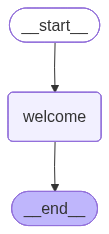

In [6]:
from IPython.display import Image, display

first_graph = graph.compile()

# You could see the errors with the below command
Image(first_graph.get_graph().draw_mermaid_png())

# You can use the below command to see the graph without errors
# print(first_graph.get_graph().draw_mermaid())

### **Step-5: Run The Graph**

In [7]:
first_graph.invoke({"name":"Ansh","message":"How are you?"})

{'name': 'Ansh',
 'message': "Your message was How are you?. Here's my response:  Nice to meet you, Ansh! I'm just a computer program, so I don't have feelings like humans do, but I'm functioning properly and ready to chat with you! How about you? How's your day going so far?"}